# 02 Pair Selection

Generate correlation candidates and apply fixed-orientation Engle–Granger tests. Selection uses raw Engle–Granger p-values at the configured 1% default, without multiple-testing correction. Saved outputs below may predate this change; rerun before interpreting them. All decisions are saved for inspection.

Run cells from top to bottom, or choose **Run All** for this notebook only. Each module saves its outputs for the next notebook. Restart the kernel after pulling code changes.


## 1. Imports and saved run


In [1]:
%matplotlib inline
from pathlib import Path
import sys
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'src' / 'research_config.py').exists()), None)
if ROOT is None:
    raise FileNotFoundError('Open Jupyter inside the Pairs_trading repository.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from src.project_io import OUTPUT_DIR, initialize, load_config, load_frame, save_frame, save_json

cfg = load_config()


## 2. Correlation candidates

Use training returns only. Each unordered candidate has one predetermined alphabetical regression direction.


In [2]:
from src.Pair_Selection import compute_returns, correlation_matrix, generate_candidate_pairs
train_prices = load_frame('train_prices')
returns = compute_returns(train_prices)
correlations = correlation_matrix(returns)
candidate_pairs = generate_candidate_pairs(correlations, cfg.correlation_neighbors)
print(f'{len(candidate_pairs):,} candidate pairs from {len(train_prices.columns)} assets')
display(pd.DataFrame(candidate_pairs, columns=['dependent', 'independent']).head(10))


3,838 candidate pairs from 466 assets


,dependent,independent
0,A,ABT
1,A,ACN
2,A,APH
3,A,BAX
4,A,BDX
5,A,COO
6,A,CRL
7,A,DHR
8,A,INCY
9,A,IQV


## 3. Cointegration and integration screens

This replaces ordinary residual ADF p-values and minimum-p orientation selection. ADF level/difference screens are diagnostics for the I(1) assumption; they do not prove it.


In [3]:
from src.Cointegration import screen_cointegration
selected, spreads, audit = screen_cointegration(train_prices, candidate_pairs,
    significance=cfg.cointegration_alpha, integration_alpha=cfg.integration_alpha)
save_frame('cointegration_audit', audit)
save_frame('cointegrated_pairs', selected)
display(audit[['pair', 'pvalue', 'multiplicity_method', 'integration_screen', 'selected']].head(20))
print(f'{len(selected)} pairs retained')
if selected.empty:
    raise ValueError('No pairs passed. The audit is saved. Review the result before changing thresholds.')


,pair,pvalue,multiplicity_method,integration_screen,selected
0,A-ABT,0.563982,none,True,False
1,A-ACN,0.218976,none,True,False
2,A-APH,0.027462,none,True,False
3,A-BAX,0.993743,none,True,False
4,A-BDX,0.700388,none,True,False
5,A-COO,0.548617,none,True,False
6,A-CRL,0.717507,none,True,False
7,A-DHR,0.111622,none,True,False
8,A-INCY,0.683143,none,True,False
9,A-IQV,0.320430,none,True,False


98 pairs retained


## 4. Save fitted spreads

Each column is a selected pair’s formation log-price residual, with alpha and beta recorded in cointegrated_pairs.


,pair,alpha,beta,pvalue
0,A-MTD,-1.907639,0.943142,0.007705
1,AAPL-MPWR,-0.863083,0.975501,0.001328
2,ABT-STE,-0.415048,0.961633,0.000833
3,ABT-ZTS,0.338157,0.841182,0.002334
4,ACN-HD,-0.404943,1.065076,0.000620
5,ADBE-DPZ,-1.949263,1.361821,0.002503
6,ADI-CDNS,2.252189,0.546839,0.005139
7,ADI-KEYS,1.934167,0.600298,0.009811
8,ADI-TXN,0.399033,0.910039,0.008192
9,ADP-MSI,1.043989,0.784577,0.000379


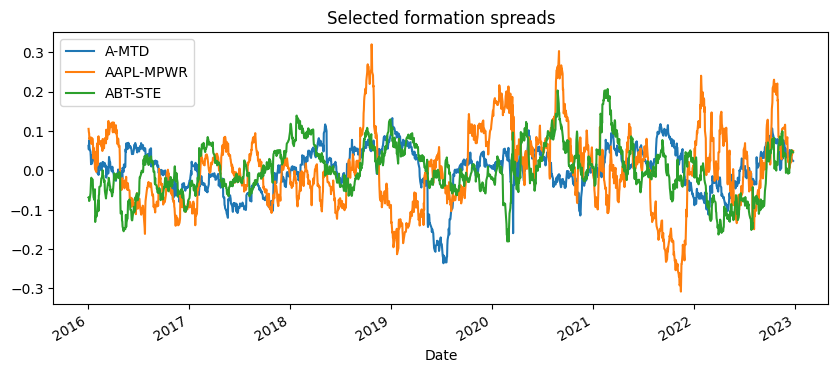

In [4]:
formation_spreads = pd.DataFrame({f'{dep}-{ind}': values for (dep, ind), values in spreads.items()})
save_frame('formation_spreads', formation_spreads)
display(selected[['pair', 'alpha', 'beta', 'pvalue']].head(10))
formation_spreads.iloc[:, :3].plot(figsize=(10, 4), title='Selected formation spreads')
plt.show()


## Save module completion

Wait for this confirmation before moving to the next notebook.


In [5]:
print(f'Completed. Files saved in {OUTPUT_DIR}')


Completed. Files saved in /home/runner/work/Pairs_trading/Pairs_trading/data/processed/current
